# Magneto-Optical Kerr Effect (MOKE)
**by <span style="color:darkgreen">Dmitrii Nabok</span> & <span style="color:darkgreen">Santiago Rigamonti</span> for [<span style="color:darkgoldenrod">exciting *magnesium*</span>](https://www.exciting-code.org/magnesium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Tejus Rohatgi</span>, <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial you will learn how to set up and execute **`exciting`** calculations of the magneto-optical Kerr effect (**MOKE**). As an example, we calculate the **MOKE** spectrum for ferromagnetic fcc-Ni.
<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">

**Table of Contents**

[0. Before Starting](#0)

[1. Previous Knowledge](#1)

[2. Theoretical background of the Magneto-Optical Kerr Effect](#2)

[3. The <b>MOKE</b> spectrum of Nickel](#3)

[4. Convergence issues](#4)
    
* [Excercise](#4-1)

[Literature](#5)

</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

**<span style="color:firebrick">Important Note:</span>** All input parameters are in **atomic units**!


<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Previous Knowledge</span>

The evaluation of the **MOKE** spectrum involves a spin polarized ground state calculation followed by a **TDDFT** calculation. Therefore, before starting, it is recommended to be familiar with the following related tutorials:

* **Spin-polarized calculations** 
* **Excited states from TDDFT**

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Theoretical Background</span>

When linearly polarized light is reflected on the surface of a ferromagnetic material, the reflected beam will be, in general, elliptically polarized with its polarization plane rotated with respect to the incident beam. The magnitude of both the polarization rotation $ \theta_K $ and the ellipticity $ \gamma_K $ are given by the complex Kerr angle:$\phi_K(\omega) = \theta_K (\omega) + i\gamma_K(\omega)$ which can be obtained from the dielectric tensor $\epsilon_{\alpha \beta}$. In particular, for the so-called polar configuration present when both incident light and the magnetic moment of the material are perpendicular to the surface, the Kerr angle is given by:

<!-- <span id="eq1"></span> -->
<a id="e1"></a>
\begin{equation}
\tag{1}
\phi_K(\omega) = -\frac{\epsilon_{xy}}{(1 - \epsilon_{xx}) \sqrt{\epsilon_{xx}}}
\end{equation}

A proper description of the **MOKE** requires knowledge of the current-current response function. However, in the **TDDFT** framework the longitudinal contraction of the dielectric tensor is obtained from the density-density response function, which lacks a part of the transverse response contained in the current-current response. This term, which is non-zero only when time-reversal symmetry is broken, is called the anomalous Hall conductivity (**AHC**) and constitutes an essential ingredient for describing magneto-orbit effects. Therefore, in the TDDFT calculation this term must be added to obtain the correct **MOKE** spectrum. In order to do that, we must set the attribute <code><span style="color:mediumblue">ahc</span></code>  to `"true"` in the <code><span style="color:green">tddft</span></code> element, as shown in the example input file of this example (see below).

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. The <b>MOKE</b> spectrum of Nickel</span>

As a first step, you may create a running directory for the notebook.

In [ ]:
%%bash -l 
mkdir -p run_moke

In order to generate the **MOKE** spectrum for nickel, we will use the following input file (**input.xml**) to run **`exciting`**:

<span class="MOKE_NICKEL_INPUT"></span>
```xml
<input>
 
   <title>FM fcc Ni</title>
 
   <structure speciespath="$EXCITINGROOT/species">
      <crystal scale="6.652">
         <basevect> 0.5  0.5  0.0 </basevect>
         <basevect> 0.5  0.0  0.5 </basevect>
         <basevect> 0.0  0.5  0.5 </basevect>
      </crystal>
      <species speciesfile="Ni.xml" rmt="2.3">
         <atom coord="0.0 0.0 0.0"/>
      </species>
   </structure>
 
   <groundstate 
      xctype="LDA_PW"
      rgkmax="7.0" 
      epsengy="1.0d-4">
 
      <spin 
         reducebf="0.5" 
         spinorb="true"/>
 
   </groundstate>
 
   <xs 
      xstype="TDDFT"
      ngridk="4 4 4"
      vkloff="0.097 0.273 0.493"
      dfoffdiag="true"
      dogroundstate="fromscratch"
      maxscl="200"
      bfieldc="0.0 0.0 -2.0"
      broad="0.02"
      tevout="true">
 
      <tddft
          fxctype="RPA"
          drude="0.18 0.001"
          ahc="true"/>
 
      <qpointset>
         <qpoint> 0.0 0.0 0.0 </qpoint>
      </qpointset>
 
      <energywindow 
         intv="0.00 0.32" points="150"/>
 
   </xs> 
 
</input>
```

In [ ]:
from excitingjupyter.utilities import get_input_xml_from_notebook

input_str = get_input_xml_from_notebook("magneto_optical_kerr_effect", "MOKE_NICKEL_INPUT")

# Write out the input as an XML file:
with open('./run_moke/input.xml', "w") as fid:
    fid.write(input_str)

<strong><span style="color:firebrick">Make sure to set</span> </strong> <code><span style="color:green">$EXCITINGROOT</span></code> to the correct exciting root directory in the <code><span style="color:mediumblue">speciespath</span></code> attribute using the command

In [ ]:
%%bash -l
cd run_moke
python3 -m excitingscripts.setup.excitingroot
cd ../

Please be aware that for time-saving reasons, here we have chosen computational parameters which do not correspond to those obtained from convergence tests. However, with them we are able to reproduce the main spectral features for the system under consideration.

Before running <code><b>exciting</b></code>, let's examine the input file displayed above. First, we consider the <code><span style="color:green">groundstate</span></code> element. Inside it we find the <code><span style="color:green">spin</span></code> element as explained in [<span style="color:red">Spin-polarized calculations</span>]() . Most importantly, we must set the <code><span style="color:mediumblue">spinorb</span></code> attribute to `"true"`, because the spin-orbit coupling is essential to obtain the Kerr rotation. As you can notice, we <strong><span style="color:firebrick">skip</span></strong> the ground-state calculation. The reason for this is that the self-consistency loop will be triggered (from scratch) by the <code><span style="color:green">xs</span></code> element, where a fine <b>k</b>-grid is defined (see below). Nevertheless, we need to set thecode><span style="color:green">groundstate</span></code> element to define several parameters, such as the type of exchange-correlation functional or the <code><span style="color:green">spin</span></code> element and its attributes. Notice that the convergence threshold for the total energy, <code><span style="color:mediumblue">epsengy</span></code>, is set to <code>"1.0d-4"</code>, which is a larger value than the default one.

Next, we consider the <code><span style="color:green">xs</span></code> element. Most of the attributes and convergence issues for that element are discussed in [<span style="color:red">Excited states from TDDFT</span>](). Therefore, we refer the reader to it in case of doubts. However, we have in this case a few additional parameters: We set the attribute <code><span style="color:mediumblue">dogroundstate</span></code> = <code>"fromscratch"</code>, meaning that we will trigger the ground-state calculation from the <code><span style="color:green">xs</span></code> element, therefore, there is no need in this case to have a previous <code><span style="color:green">groundstate</span></code> run. We set also <code><span style="color:mediumblue">maxscl</span></code> to ,<code>"200"</code> and <code><span style="color:mediumblue">bfieldc</span></code> to a finite value in the <b>z</b>-direction. Both attributes have exactly the same meaning as their homonyms in the <code><span style="color:green">groundstate</span></code> element. Inside the <code><span style="color:green">tddft</span></code> element, we must set <code><span style="color:mediumblue">ahc</span></code> to <code>"true"</code> in order to include the anomalus Hall conductivity term to the <b>TDDFT</b> response functions, as explained in the theoretical section.

In order to run <code><b>exciting</b></code> create the <b>input.xml</b> from the example above and run the scripts

In [ ]:
%%bash -l 
cd run_moke
mkdir -p k444
cd k444
cp ../input.xml ./
python3 -m excitingscripts.execute.single --verbose -f input.xml
cd ../../ 

After the completion of the run, all results will be written inside the directory **k444**. In particular for the **MOKE**, the relevant file is called **MOKE_label.OUT**. In order to visualize the **MOKE** spectrum, move to the directory **k444** and run the following script:

In [ ]:
%%bash -l
cd run_moke/k444

#extracting the thetha_k and gamma_k values
awk '{print $1, $2}' MOKE_*.OUT > theta_K
awk '{print $1, $3}' MOKE_*.OUT > gamma_K

python3 -m excitingscripts.plot.files -f theta_K gamma_K -cy 2  -ll '$\theta_K$' '$\gamma_K$'  -lx 'Energy [eV]'  -ly 'Kerr angle [deg]' -x 0 9 -y -0.4 0.3 -mtx 10
cd ../../

The resulting plot is saved in the file <b>PLOT.png</b>, which should look like in the following image: 

<figure>
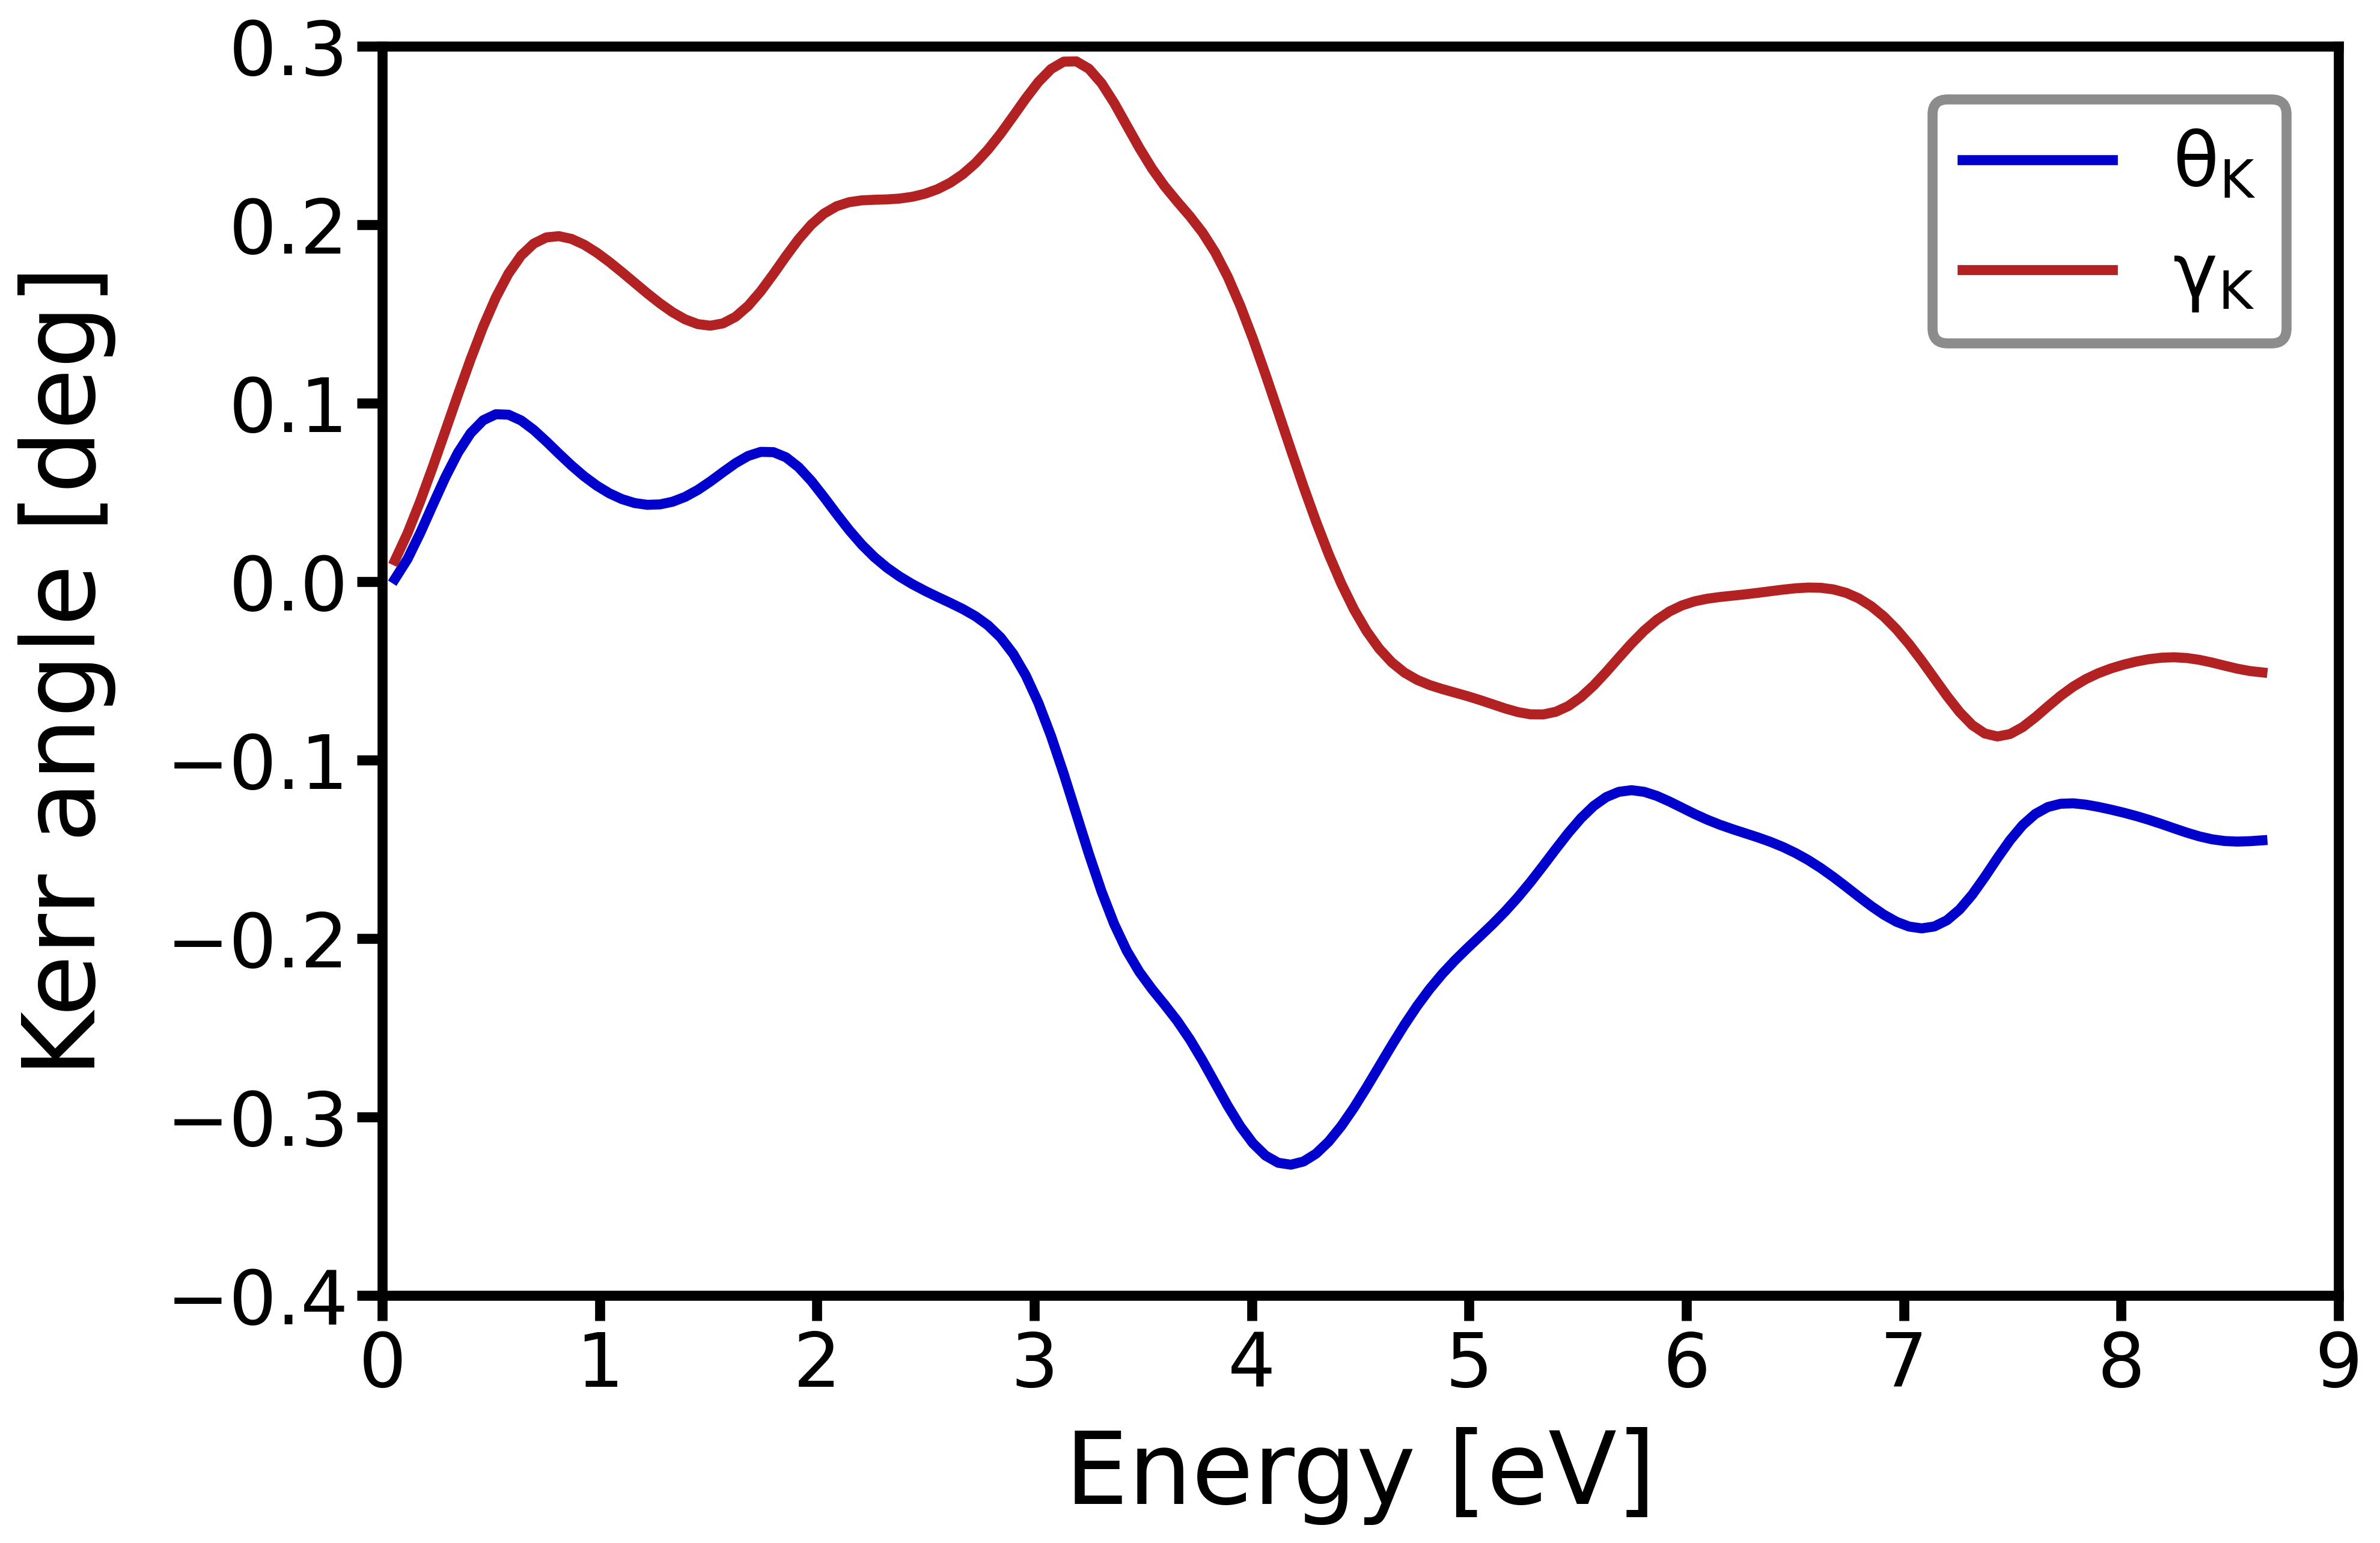
</figure>

<a id='4'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">4. Convergence issues</span>

In the calculation of optical properties, two of the most important convergence parameters are the size of the <b>k</b>-point grid and the number of empty states included in the calculation of the response function. They are controlled, respectively, by the attributes <code><span style="color:mediumblue">ngridk</span></code> and <code><span style="color:mediumblue">nempty</span></code> of the <code><span style="color:green">xs</span></code> element. It is important to note that to obtain convergent optical spectra one has to use rather large <b>k</b>-point sets. In addition, the attribute <code><span style="color:mediumblue">nempty</span></code> plays now not only the role of a convergence parameter for spin-polarized calculations. In this case, one has to be sure that the excited (empty) states are covering the energy range where the <b>MOKE</b> spectrum is searched. Additionally, as we are dealing with a metal system, the smearing of the <b>k</b>-points (controlled by the attributes <code><span style="color:mediumblue">stype</span></code> and <code><span style="color:mediumblue">swidth</span></code> of the <code><span style="color:green">groundstate</span></code> element) can play an important role to reach convergence.

<hr style="border:1px solid #DDD"> </hr>
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Show the spectra obtained for "ngridk" = "10 10 10"</span></strong></summary> 
    
<figure>
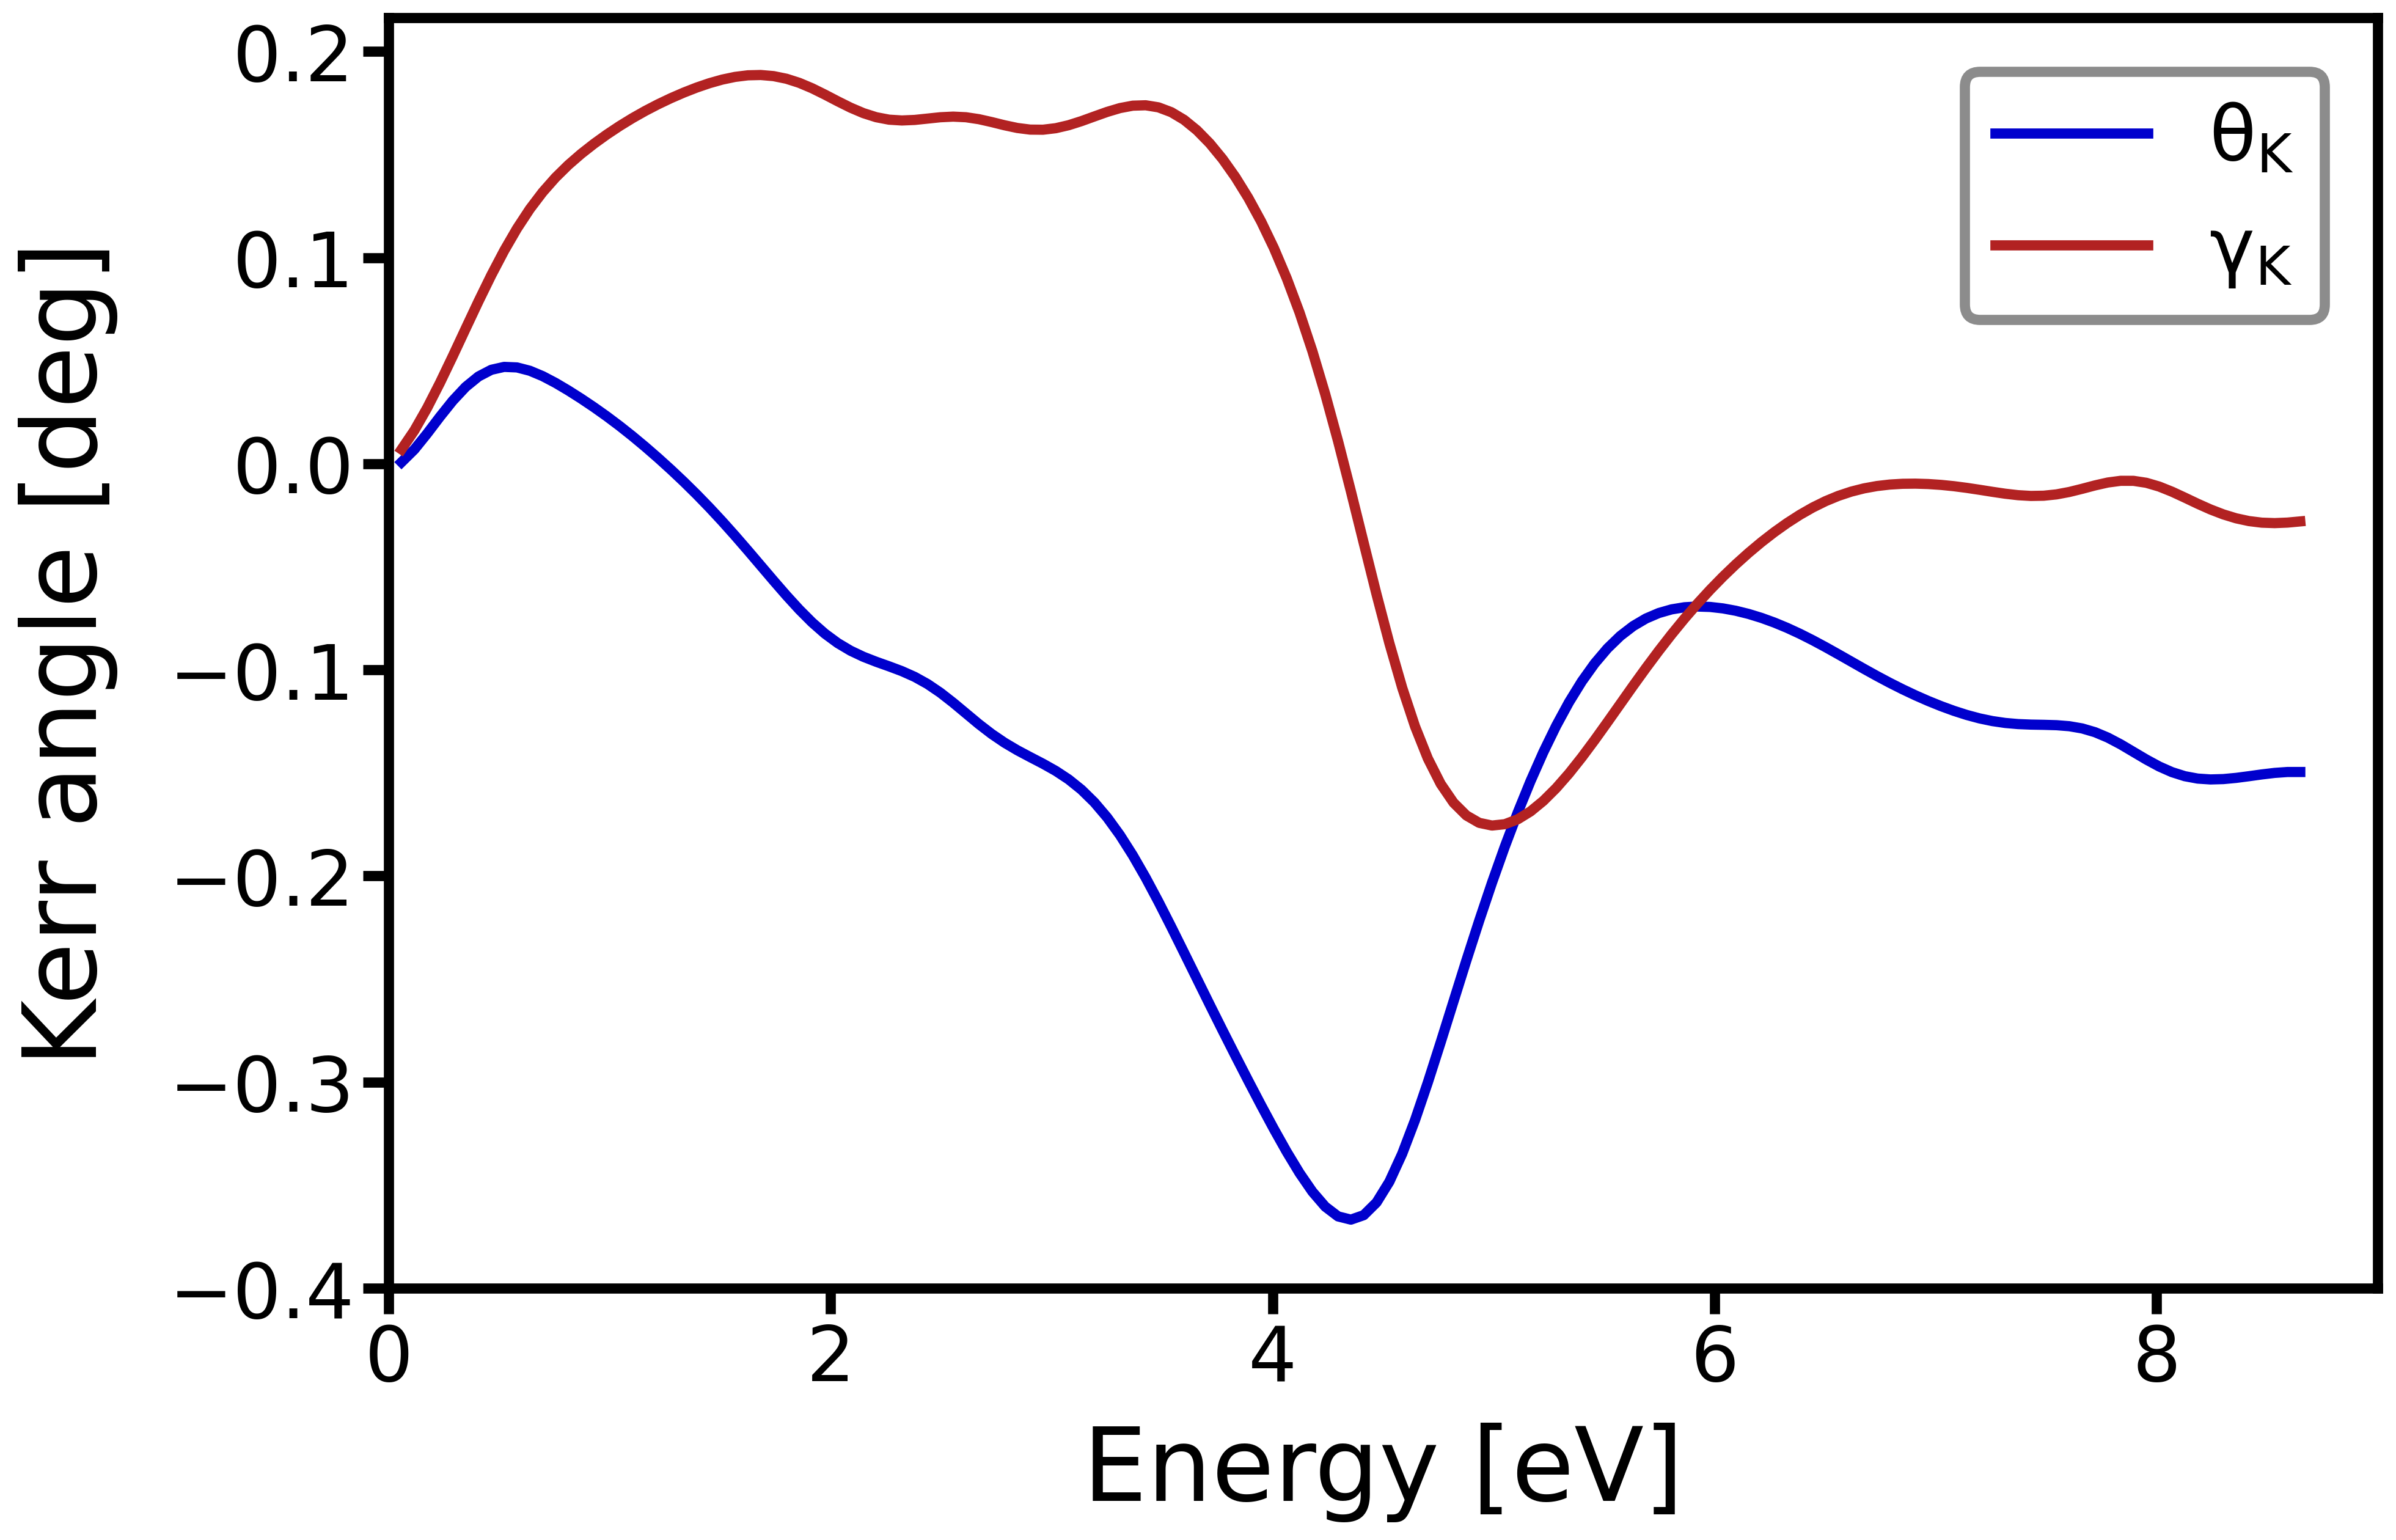
</figure>
</details>
<hr style="border:1px solid #DDD"> </hr>


<a id='4-1'></a>
<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Excercise</b></span>

* In this tutorial we are using the default value for the <code><span style="color:mediumblue">ngridk</span></code> attribute. Check if this selection is enough to obtain a reasonable spectrum in the energy range between 0 and 8 eV (Hint: Inspect the file <b>EIGVAL_QMT001.OUT</b>).
* Perform the complete convergence test to get the value of the magnetic moment of FM fcc-Ni and compare it with the experimental value of ~0.6 μB.
* Use the default value for the attribute <code><span style="color:mediumblue">epsengy</span></code> and repeat the calculations. Is there any difference in the calculated spectra?
* Converge the **MOKE** spectrum with respect to <code><span style="color:mediumblue">ngridk</span></code> size.
* As a matter of fact, the **MOKE** is mainly due to presence of the spin-orbit coupling. One can readily check it by recalculating the spectrum by setting <code><span style="color:mediumblue">spinorb</span></code> = <code>"false"</code>.
</div>

<a id='5'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">Literature</span>

* J. Kunes, Physica Scripta <b>T109</b>, 116 (2004)
* D. Sangalli, A. Marini, and A. Debernardi, Phys. Rev. B <b>86</b>, 125139 (2012)

<hr style="border:2px solid #DDD"> </hr>